<a href="https://colab.research.google.com/github/ChiriKamau/soma/blob/main/notebooks/In_school.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# --- Libraries ---
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# --- Constants ---
counties_list = [
    "BARINGO","BOMET","BUNGOMA","BUSIA","ELGEYO-MARAKWET","EMBU","GARISSA",
    "HOMA BAY","ISIOLO","KAJIADO","KAKAMEGA","KERICHO","KIAMBU","KILIFI",
    "KIRINYAGA","KISII","KISUMU","KITUI","KWALE","LAIKIPIA","LAMU","MACHAKOS",
    "MAKUENI","MANDERA","MARSABIT","MERU","MIGORI","MOMBASA","MURANGA",
    "NAIROBI","NAKURU","NANDI","NAROK","NYAMIRA","NYANDARUA","NYERI",
    "SAMBURU","SIAYA","TAITA-TAVETA","TANA RIVER","THARAKA-NITHI","TRANS NZOIA",
    "TURKANA","UASIN GISHU","VIHIGA","WAJIR","WEST POKOT"
]


In [3]:

# Load CSV (skip first row if it’s a multi-header)
url = "https://raw.githubusercontent.com/ChiriKamau/soma/main/data/distribution-of-population-age-3-years-and-above-by-school-attendance-status-area-of-residence-s.csv"
df = pd.read_csv(url, skiprows=1)

# Strip column names
df.columns = df.columns.str.strip()

# Optional: view first rows
df.head()

# Assign to df_clean
df_clean = df.copy()


In [4]:
# Identify relevant columns from the cleaned dataframe
area_col, school_col = df_clean.columns[0], df_clean.columns[2]  # Column 0 = County/Sub-County, Column 2 = At School

# Filter only main counties
county_data = df_clean[df_clean[area_col].str.upper().isin(counties_list)].drop_duplicates(subset=[area_col]).copy()

# Clean numeric values in school column
county_data[school_col] = pd.to_numeric(
    county_data[school_col].astype(str)
               .str.replace(',', '')
               .str.replace('"', ''),
    errors='coerce'
)

# Sort counties alphabetically
county_data = county_data.sort_values(by=area_col).reset_index(drop=True)


In [5]:
# Counties found in the CSV
found_counties = county_data[area_col].str.upper().unique()

# Counties missing from CSV
missing_counties = [c for c in counties_list if c not in found_counties]

print(f"Found {len(found_counties)} counties:")
for _, row in county_data.iterrows():
    if pd.notna(row[school_col]):
        print(f"{row[area_col]}: {row[school_col]:,.0f} people in school")

print(f"\nMissing {len(missing_counties)} counties:")
for county in missing_counties:
    print(f"- {county}")


Found 47 counties:
BARINGO: 253,878 people in school
BOMET: 400,330 people in school
BUNGOMA: 782,677 people in school
BUSIA: 405,072 people in school
ELGEYO-MARAKWET: 203,979 people in school
EMBU: 205,389 people in school
GARISSA: 132,990 people in school
HOMA BAY: 539,753 people in school
ISIOLO: 79,881 people in school
KAJIADO: 389,090 people in school
KAKAMEGA: 853,031 people in school
KERICHO: 387,109 people in school
KIAMBU: 778,586 people in school
KILIFI: 605,776 people in school
KIRINYAGA: 193,518 people in school
KISII: 557,477 people in school
KISUMU: 504,812 people in school
KITUI: 490,726 people in school
KWALE: 334,612 people in school
LAIKIPIA: 184,613 people in school
LAMU: 50,249 people in school
MACHAKOS: 505,677 people in school
MAKUENI: 395,627 people in school
MANDERA: 168,647 people in school
MARSABIT: 108,132 people in school
MERU: 554,475 people in school
MIGORI: 522,757 people in school
MOMBASA: 378,423 people in school
MURANGA: 358,844 people in school
NAIROB

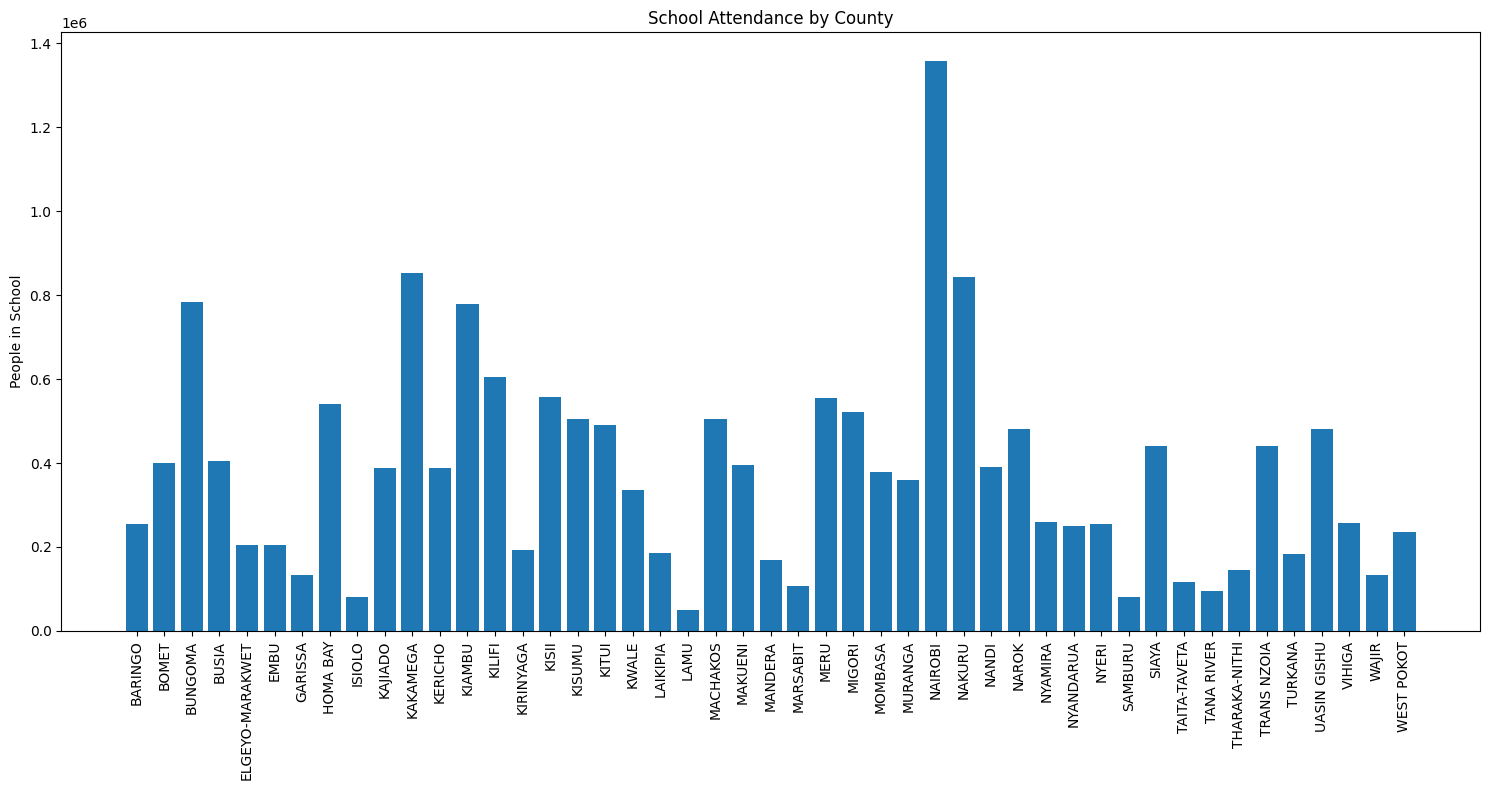

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plt.bar(county_data[area_col], county_data[school_col])
plt.xticks(rotation=90)
plt.ylabel('People in School')
plt.title('School Attendance by County')
plt.tight_layout()
plt.show()

In [7]:
# Load population CSV
url_pop = "https://raw.githubusercontent.com/ChiriKamau/soma/main/data/Population_scounty_age_gender.csv"
df_pop = pd.read_csv(url_pop)

# Convert numeric columns
df_pop["Age"] = pd.to_numeric(df_pop["Age"], errors='coerce')
df_pop["Total"] = pd.to_numeric(df_pop["Total"], errors='coerce').fillna(0)

# Filter ages 3-20
df_under_20 = df_pop[(df_pop["Age"] >= 4) & (df_pop["Age"] <= 20)]

# Sum by county
county_pop = df_under_20.groupby("ewcounty")["Total"].sum().reset_index()
county_pop["ewcounty"] = county_pop["ewcounty"].str.upper()

# Filter for our 47 counties
county_under_20 = county_pop[county_pop["ewcounty"].isin(counties_list)]

# Sort counties alphabetically
county_under_20 = county_under_20.sort_values(by="ewcounty").reset_index(drop=True)



In [8]:
# Uppercase matched counties
matched_counties = county_under_20['ewcounty'].str.upper().tolist()

# Determine unmatched counties
unmatched_counties = [c for c in counties_list if c not in matched_counties]

# Print matched counties with population
print("Matched Counties (with population under 20):")
for _, row in county_under_20.iterrows():
    print(f"{row['ewcounty']}: {row['Total']:,.0f} people")

# Print unmatched counties
print("\nUnmatched Counties (no data found):")
for county in unmatched_counties:
    print(f"- {county}")

# Print total population under 20 for matched counties
print(f"\nTotal under 20 across matched counties: {county_under_20['Total'].sum():,.0f}")



Matched Counties (with population under 20):
BARINGO: 637,972 people
BOMET: 810,884 people
BUNGOMA: 1,630,506 people
BUSIA: 851,494 people
ELGEYO-MARAKWET: 417,552 people
EMBU: 432,240 people
GARISSA: 903,652 people
HOMA BAY: 1,082,794 people
ISIOLO: 255,634 people
KAJIADO: 863,568 people
KAKAMEGA: 1,770,970 people
KERICHO: 787,026 people
KIAMBU: 1,562,282 people
KILIFI: 1,318,498 people
KIRINYAGA: 394,942 people
KISII: 1,145,180 people
KISUMU: 999,872 people
KITUI: 1,035,980 people
KWALE: 796,370 people
LAIKIPIA: 418,582 people
LAMU: 118,410 people
MACHAKOS: 1,041,418 people
MAKUENI: 820,014 people
MANDERA: 985,544 people
MARSABIT: 468,296 people
MERU: 1,202,608 people
MIGORI: 1,089,168 people
MOMBASA: 799,598 people
MURANGA: 753,950 people
NAIROBI: 2,705,328 people
NAKURU: 1,751,206 people
NANDI: 782,272 people
NAROK: 1,141,812 people
NYAMIRA: 534,486 people
NYANDARUA: 516,696 people
NYERI: 504,636 people
SAMBURU: 315,336 people
SIAYA: 901,522 people
TAITA-TAVETA: 252,302 people
TANA

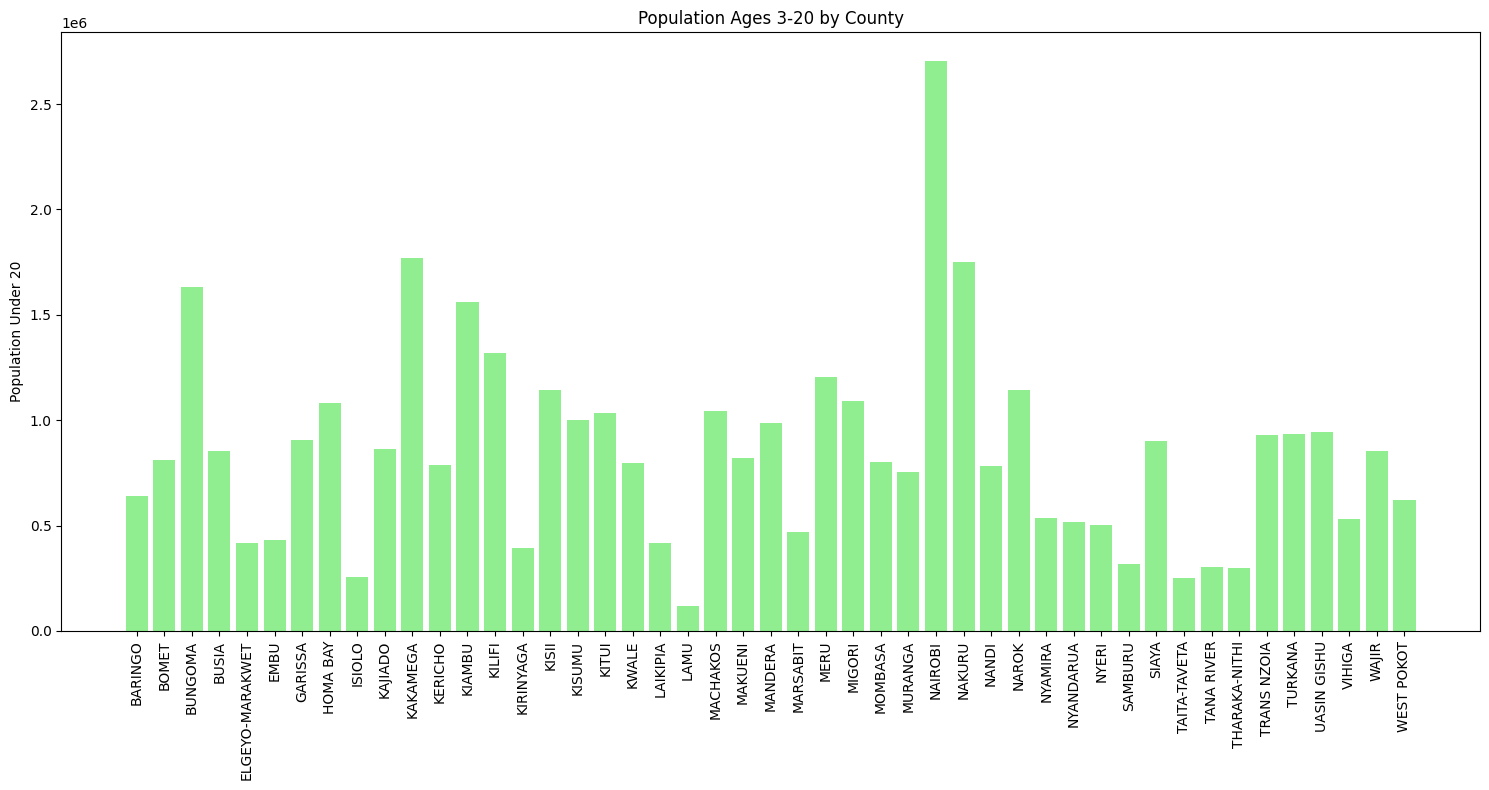

In [9]:
plt.figure(figsize=(15,8))
plt.bar(county_under_20["ewcounty"], county_under_20["Total"], color='lightgreen')
plt.xticks(rotation=90)
plt.ylabel('Population Under 20')
plt.title('Population Ages 3-20 by County')
plt.tight_layout()
plt.show()


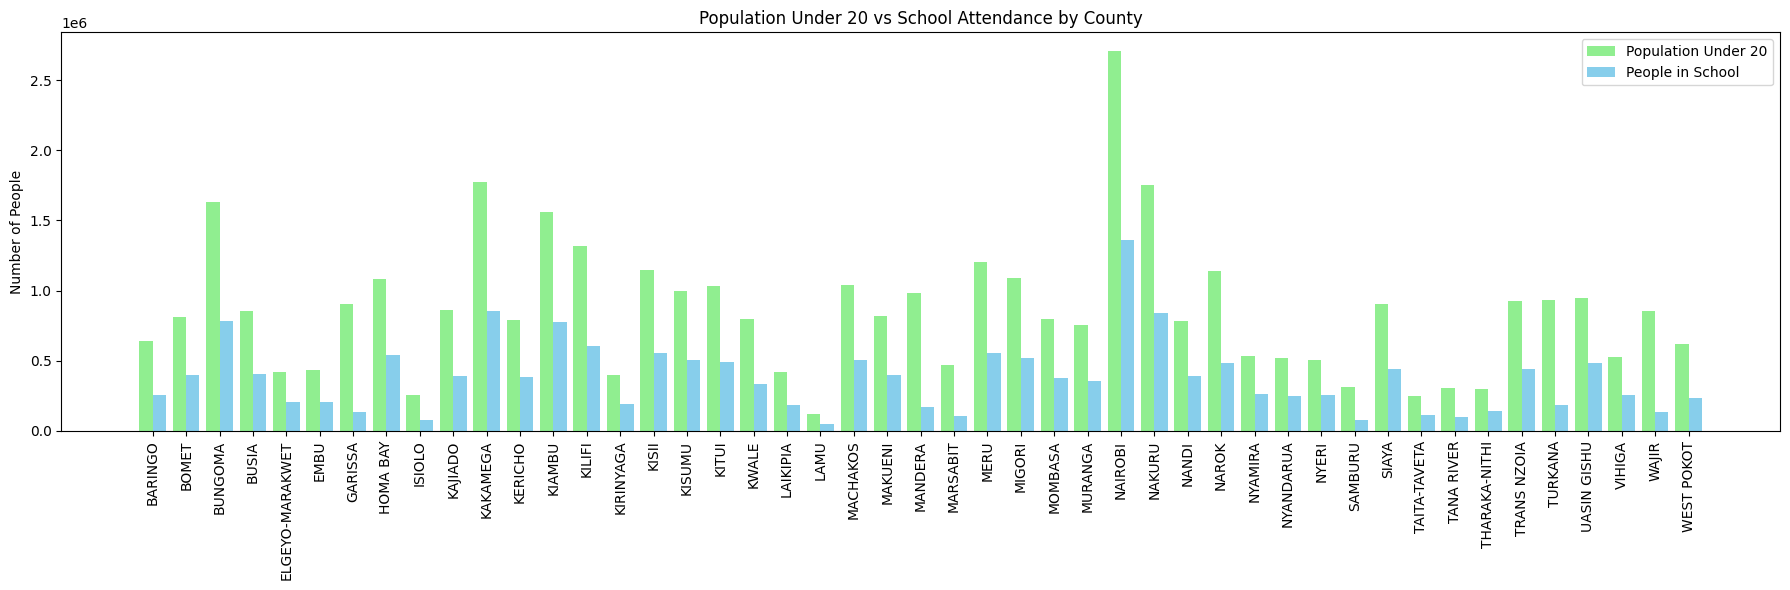

In [10]:

# X positions
x = np.arange(len(county_under_20))  # one for each county
width = 0.4  # width of the bars

# Create figure
plt.figure(figsize=(18, 6))

# Bar for population under 20
plt.bar(x - width/2, county_under_20["Total"], width=width, color='lightgreen', label='Population Under 20')

# Bar for people in school
plt.bar(x + width/2, county_data[school_col], width=width, color='skyblue', label='People in School')

# Labels and title
plt.xticks(x, county_under_20["ewcounty"], rotation=90)
plt.ylabel("Number of People")
plt.title("Population Under 20 vs School Attendance by County")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:


# Load data
url_edu = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/distribution-of-population-age-3-years-and-above-by-highest-level-of-education-reached-2019-cens.csv"
df_edu = pd.read_csv(url_edu)

# Uppercase county/sub-county names for consistent matching
df_edu[df_edu.columns[0]] = df_edu[df_edu.columns[0]].str.upper()

# List of columns to keep (education levels)
edu_columns = [
    "Pre-Primary",
    "Primary",
    "Secondary",
    "Technical and Vocational Training (TVET)",
    "University"
]

# Keep only main counties
county_data_edu = df_edu[df_edu[df_edu.columns[0]].isin([c.upper() for c in counties_list])].copy()

# Clean numeric columns: remove commas and convert to numbers
for col in edu_columns:
    county_data_edu[col] = pd.to_numeric(
        county_data_edu[col].astype(str).str.replace(',', '').str.replace('"', ''),
        errors='coerce'
    )

# Reset index
county_data_edu = county_data_edu.reset_index(drop=True)

# Sort alphabetically by county
county_data_edu = county_data_edu.sort_values(by=df_edu.columns[0]).reset_index(drop=True)

# Show the final table
county_data_edu[[df_edu.columns[0]] + edu_columns]


,County/ Sub-County,Pre-Primary,Primary,Secondary,Technical and Vocational Training (TVET),University
0,BARINGO,50032,229993,114769,33737,15116
1,BOMET,71308,414383,171667,47835,23397
2,BUNGOMA,153039,750369,351354,76018,35503
3,BUSIA,85338,417541,159918,32418,14890
4,BUSIA,11825,63297,27153,6253,3085
5,ELGEYO-MARAKWET,42229,198277,89263,22266,9792
6,EMBU,39879,271496,146805,39939,17266
7,GARISSA,14038,80657,41670,7414,4247
8,GARISSA,4033,25456,15688,4116,2795
9,HOMA BAY,127940,525610,211337,44943,23788


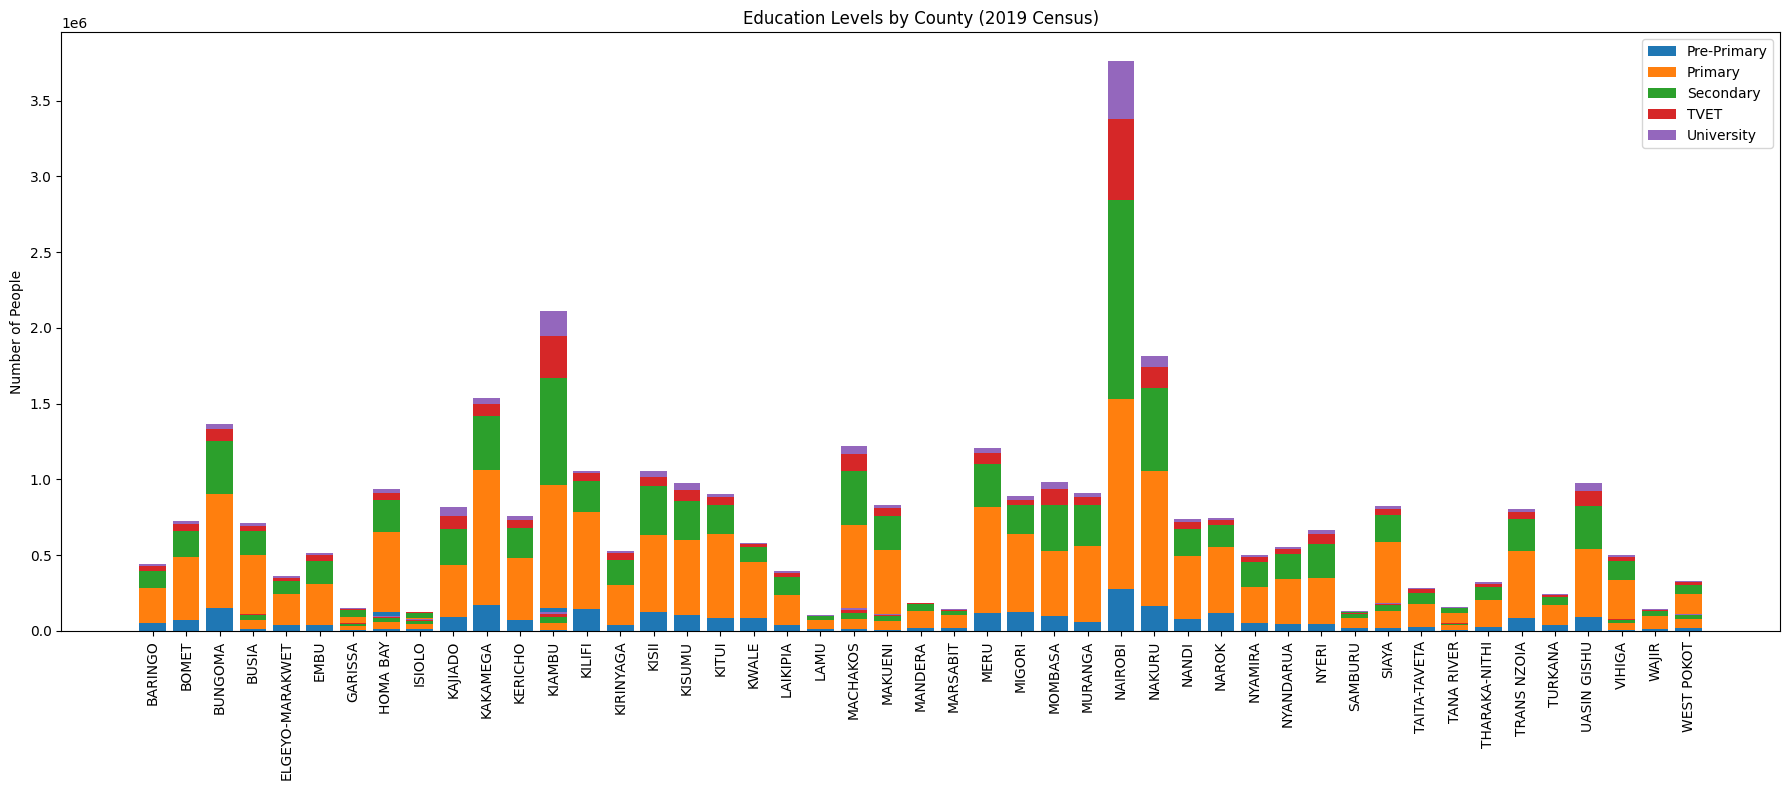

In [17]:
import matplotlib.pyplot as plt

# X-axis: county names
x = county_data_edu[df_edu.columns[0]]

# Plot stacked bars
plt.figure(figsize=(18, 8))
plt.bar(x, county_data_edu["Pre-Primary"], label="Pre-Primary")
plt.bar(x, county_data_edu["Primary"], bottom=county_data_edu["Pre-Primary"], label="Primary")
plt.bar(x, county_data_edu["Secondary"], bottom=county_data_edu["Pre-Primary"]+county_data_edu["Primary"], label="Secondary")
plt.bar(
    x, county_data_edu["Technical and Vocational Training (TVET)"],
    bottom=county_data_edu["Pre-Primary"] + county_data_edu["Primary"] + county_data_edu["Secondary"],
    label="TVET"
)
plt.bar(
    x, county_data_edu["University"],
    bottom=county_data_edu["Pre-Primary"] + county_data_edu["Primary"] + county_data_edu["Secondary"] + county_data_edu["Technical and Vocational Training (TVET)"],
    label="University"
)

# Labels and layout
plt.xticks(rotation=90)
plt.ylabel("Number of People")
plt.title("Education Levels by County (2019 Census)")
plt.legend()
plt.tight_layout()
plt.show()


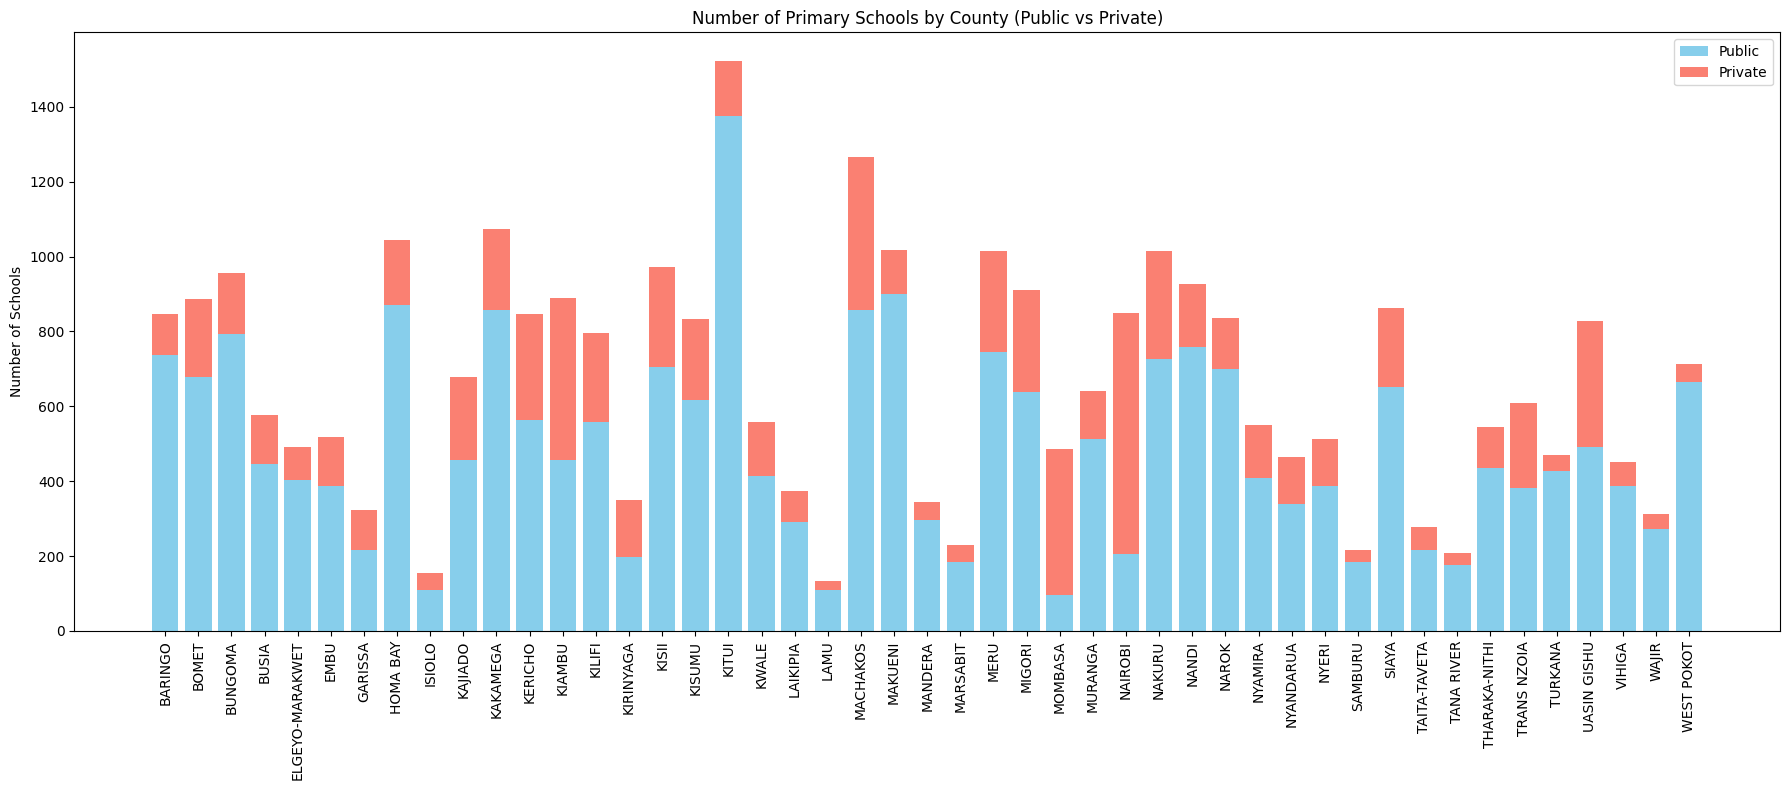

In [13]:
url = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/No_primary_school.csv"
df_schools = pd.read_csv(url)

# Ensure county names match your counties_list
df_schools["County"] = df_schools["County"].str.upper()
df_schools = df_schools[df_schools["County"].isin(counties_list)]

# Sort by counties_list order
df_schools["County"] = pd.Categorical(df_schools["County"], categories=counties_list, ordered=True)
df_schools = df_schools.sort_values("County")

# Plotting
plt.figure(figsize=(18, 8))
plt.bar(df_schools["County"], df_schools["Public_Primary_Schools"], label="Public", color="skyblue")
plt.bar(df_schools["County"], df_schools["Private_Primary_Schools"], bottom=df_schools["Public_Primary_Schools"],
        label="Private", color="salmon")

plt.xticks(rotation=90)
plt.ylabel("Number of Schools")
plt.title("Number of Primary Schools by County (Public vs Private)")
plt.legend()
plt.tight_layout()
plt.show()

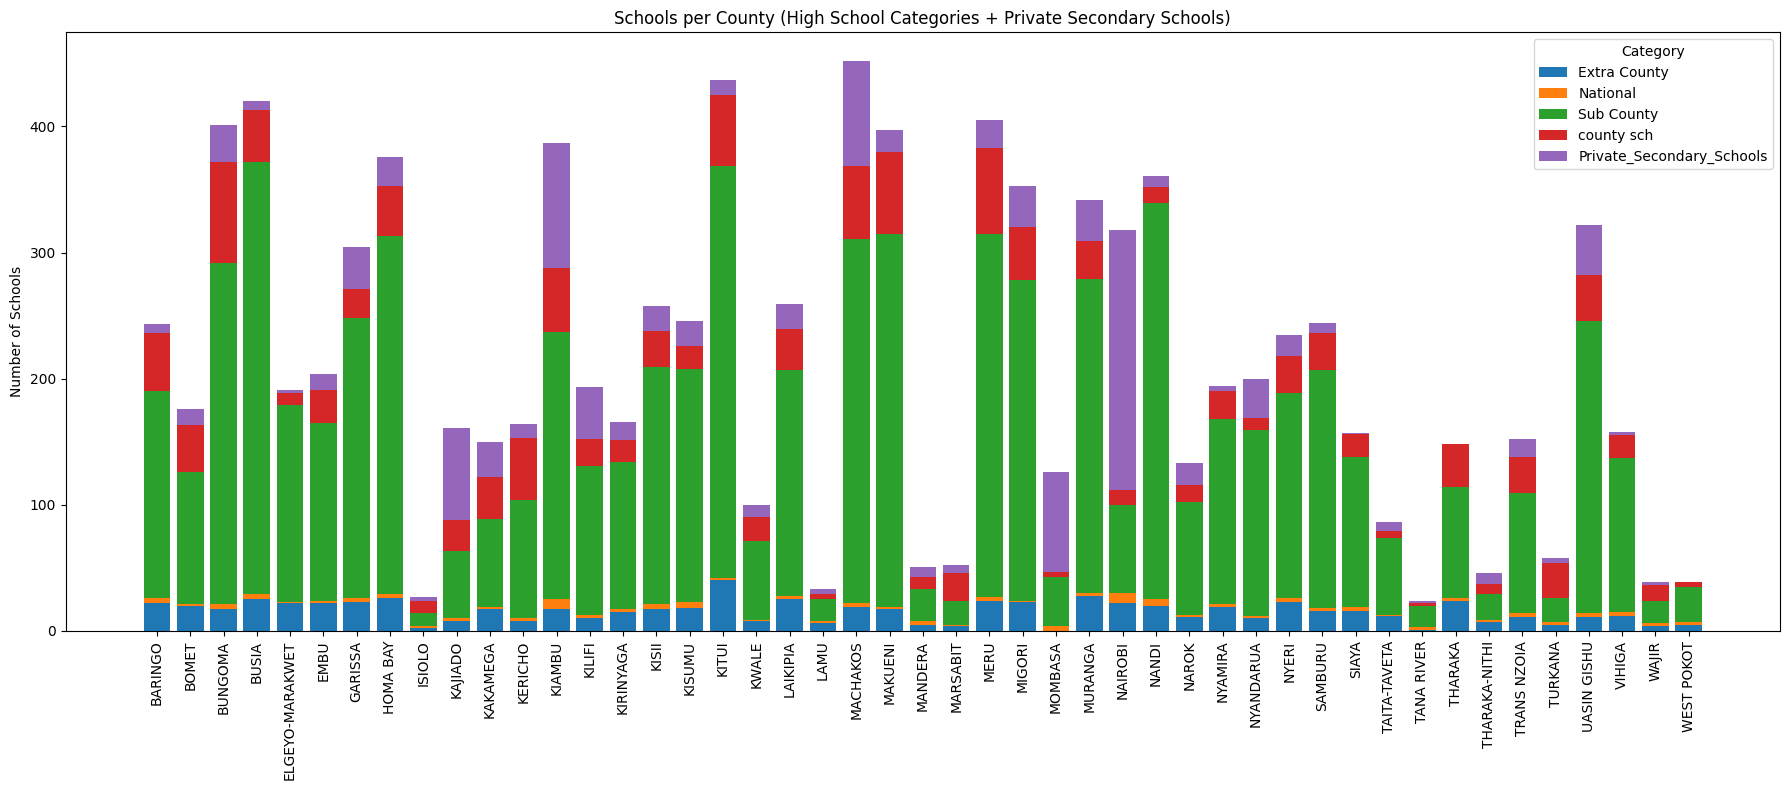

In [14]:

url = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/high_schools_data.csv"
df = pd.read_csv(url)

# County mapping
county_map = {
    "01": "TAITA-TAVETA", "02": "KWALE", "03": "MOMBASA", "04": "KILIFI", "05": "LAMU",
    "06": "TANA RIVER", "07": "NYANDARUA", "08": "NYERI", "09": "KIRINYAGA", "10": "MURANGA",
    "11": "KIAMBU", "12": "MACHAKOS", "13": "KITUI", "14": "EMBU", "15": "MERU",
    "16": "THARAKA-NITHI", "17": "ISIOLO", "18": "MAKUENI", "19": "THARAKA", "20": "NAIROBI",
    "21": "TURKANA", "22": "WEST POKOT", "23": "SAMBURU", "24": "TRANS NZOIA", "25": "UASIN GISHU",
    "26": "ELGEYO-MARAKWET", "27": "NANDI", "28": "BARINGO", "29": "LAIKIPIA", "30": "NAROK",
    "31": "KAJIADO", "32": "KERICHO", "33": "BOMET", "34": "KAKAMEGA", "35": "VIHIGA",
    "36": "BUNGOMA", "37": "BUSIA", "38": "SIAYA", "39": "KISUMU", "40": "HOMA BAY",
    "41": "MIGORI", "42": "KISII", "43": "NYAMIRA", "44": "GARISSA", "45": "WAJIR",
    "46": "MANDERA", "47": "MARSABIT"
}

df["School_Code"] = df["School_Code"].astype(str).str.zfill(8)
df["County_Code"] = df["School_Code"].str[:2]
df["County"] = df["County_Code"].map(county_map)

# --- Step 2: Create pivot table for high school categories ---
pivot = df.pivot_table(
    index="County",
    columns="Category",
    values="School_Name",
    aggfunc="count",
    fill_value=0
)
pivot["Total"] = pivot.sum(axis=1)

# --- Step 3: Load secondary school data ---
url_secondary = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/No_Secondary_schools.csv"
df_secondary = pd.read_csv(url_secondary)
df_secondary["County"] = df_secondary["County"].str.upper()

# Convert private secondary schools to numeric
df_secondary["Private_Secondary_Schools"] = pd.to_numeric(
    df_secondary["Private_Secondary_Schools"], errors='coerce'
).fillna(0).astype(int)

# Keep only County + private secondary schools
df_secondary_subset = df_secondary[["County", "Private_Secondary_Schools"]]

# --- Step 4: Merge pivot with private secondary schools ---
pivot_reset = pivot.copy()
pivot_reset.index.name = None
pivot_reset['County'] = pivot_reset.index
pivot_reset = pivot_reset.reset_index(drop=True)

# Merge
combined = pd.merge(pivot_reset, df_secondary_subset, on="County", how="left")
combined["Private_Secondary_Schools"] = combined["Private_Secondary_Schools"].fillna(0)

# Update total to include private secondary schools
combined["Total"] = combined["Total"] + combined["Private_Secondary_Schools"]

# --- Step 5: Plot stacked bar chart ---
plt.figure(figsize=(18, 8))
categories = [col for col in combined.columns if col not in ["County", "Total"]]
bottom = pd.Series([0]*combined.shape[0])

for cat in categories:
    plt.bar(combined["County"], combined[cat], bottom=bottom, label=cat)
    bottom += combined[cat]

plt.xticks(rotation=90)
plt.ylabel("Number of Schools")
plt.title("Schools per County (High School Categories + Private Secondary Schools)")
plt.legend(title="Category")
plt.tight_layout()
plt.show()


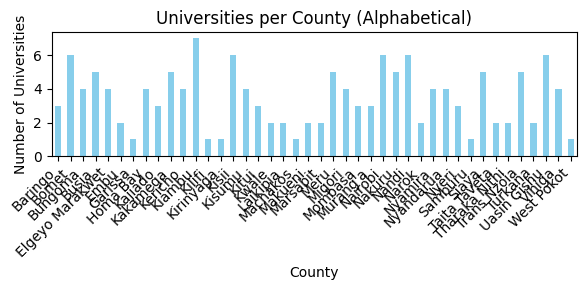

In [22]:

url = "https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/list_of_university.csv"
df_universities = pd.read_csv(url)

# Count universities per county and sort alphabetically
counts = df['County'].value_counts().sort_index()

# Simple bar plot
counts.plot(kind='bar', figsize=(6,3), color='skyblue')
plt.title("Universities per County (Alphabetical)")
plt.ylabel("Number of Universities")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


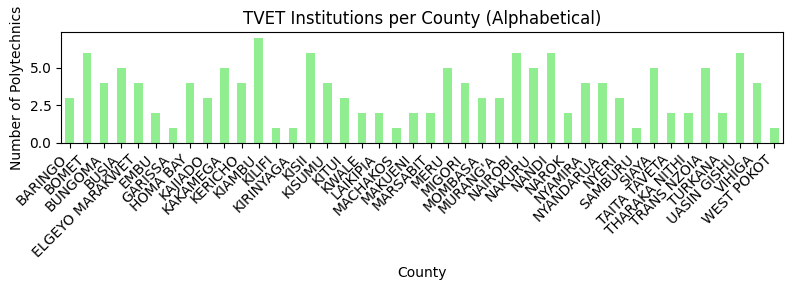

In [39]:

df_tvets = pd.read_csv("https://raw.githubusercontent.com/ChiriKamau/soma/refs/heads/main/data/TVET_Institutions_Clean.csv")
df_tvets['County'] = df_tvets['County'].str.upper().str.strip()

# Count TVET institutions per county and map to main dataframe
tvet_counts = df_tvets['County'].value_counts()
level_school_df["TVET_Schools"] = level_school_df["County"].map(tvet_counts).fillna(0)

# Plot TVET counts per county
tvet_counts.sort_index().plot(kind='bar', figsize=(8,3), color='lightgreen')
plt.title("TVET Institutions per County (Alphabetical)")
plt.ylabel("Number of Polytechnics")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [45]:

level_school_df = pd.DataFrame({"County": counties_list})

# --- Map population per education level ---
edu_levels = ["Pre-Primary", "Primary", "Secondary", "Technical and Vocational Training (TVET)", "University"]
for col in edu_levels:
    level_school_df[f"{col.replace(' ', '_').replace('(TVET)','TVET')}_People"] = level_school_df["County"].map(
        dict(zip(county_data_edu[county_data_edu.columns[0]].values, county_data_edu[col].values))
    )

# --- Map school counts per level (fill missing with 0) ---
level_school_df["Primary_Schools"] = level_school_df["County"].map(
    dict(zip(df_schools["County"], df_schools["Public_Primary_Schools"] + df_schools["Private_Primary_Schools"]))
).fillna(0)

level_school_df["Secondary_Schools"] = level_school_df["County"].map(
    dict(zip(combined["County"], combined["Total"]))
).fillna(0)

# --- TVET counts (normalized counties) ---
tvet_counts = df_tvets['County'].value_counts()
level_school_df["TVET_Schools"] = level_school_df["County"].map(tvet_counts).fillna(0)

# --- University school counts ---
uni_counts = df_universities['County'].value_counts()
level_school_df["University_Schools"] = level_school_df["County"].map(uni_counts).fillna(0)

# --- Check result ---
level_school_df.head()


,County,Pre-Primary_People,Primary_People,Secondary_People,Technical_and_Vocational_Training_TVET_People,University_People,Primary_Schools,Secondary_Schools,TVET_Schools,University_Schools
0,BARINGO,50032,229993,114769,33737,15116,846,243.0,3.0,0.0
1,BOMET,71308,414383,171667,47835,23397,887,176.0,6.0,1.0
2,BUNGOMA,153039,750369,351354,76018,35503,955,401.0,4.0,1.0
3,BUSIA,11825,63297,27153,6253,3085,578,420.0,5.0,1.0
4,ELGEYO-MARAKWET,42229,198277,89263,22266,9792,492,191.0,0.0,0.0


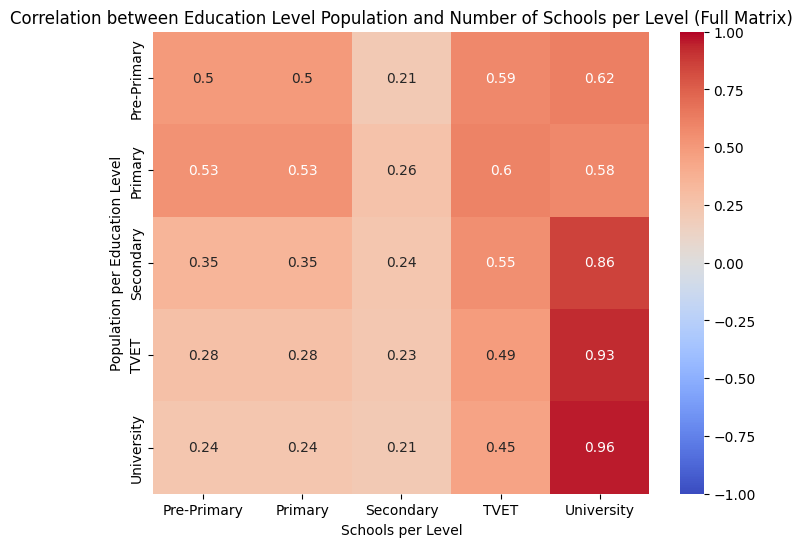

In [43]:
# Prepare labels and columns
edu_cols = ["Pre-Primary_People", "Primary_People", "Secondary_People", "Technical_and_Vocational_Training_TVET_People", "University_People"]
school_cols = ["Primary_Schools", "Primary_Schools", "Secondary_Schools", "TVET_Schools", "University_Schools"]
edu_labels = ["Pre-Primary", "Primary", "Secondary", "TVET", "University"]

# Compute full correlation matrix
corr_matrix = pd.DataFrame(index=edu_labels, columns=edu_labels)

for i, edu in enumerate(edu_cols):
    for j, school in enumerate(school_cols):
        corr_matrix.iloc[i, j] = level_school_df[edu].corr(level_school_df[school])

# Convert to numeric
corr_matrix = corr_matrix.astype(float)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.xlabel("Schools per Level")
plt.ylabel("Population per Education Level")
plt.title("Correlation between Education Level Population and Number of Schools per Level (Full Matrix)")
plt.show()


# **Linear Regression on Secondary School Categories and University PopulationP**

---

**Objective:**
We want to understand how different categories of secondary schools in Kenya influence the number of students progressing to university. Categories include National, Extra County, Sub County, and Private Secondary Schools.

**Steps Taken:**

1. **Prepare Predictors (X):**

   * We selected only numeric columns representing the number of schools per category.
   * Columns used: `National`, `Extra County`, `Sub County`, `Private_Secondary_Schools`.
   * These are the features that might influence university enrollment.

2. **Scale Features:**

   * Used `StandardScaler()` to standardize X.
   * Standardization ensures that each school category contributes equally to the regression and that scale differences do not distort the results.

3. **Prepare Target (y):**

   * `y = level_school_df["University_People"]`
   * This is the number of people enrolled in university per county.

4. **Fit Linear Regression:**

   * Used `LinearRegression()` from scikit-learn.
   * The model learns coefficients for each school category showing their effect on university population.

5. **Interpret Coefficients:**

   * Each coefficient shows the **strength and direction of influence**:

     * Positive coefficient → more schools in this category → higher university population.
     * Larger coefficient → stronger effect.

6. **R² Score:**

   * Indicates the proportion of variance in university population explained by the school categories.
   * Higher R² → better model fit.

**Why the hell do this:**

* Quantifies the impact of different secondary school types on university progression.
* Helps identify which school categories are most effective at preparing students for university.
* Provides a data-driven approach to education planning and policy decisions.

---




In [54]:
# Check column names
print(combined.columns)


Index(['Extra County', 'National', 'Sub County', 'county sch', 'Total',
       'County', 'Private_Secondary_Schools'],
      dtype='object')


In [55]:
X = combined[["National", "Extra County","county sch", "Sub County", "Private_Secondary_Schools"]].fillna(0)


In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Target
y = level_school_df["University_People"]

# Fit model
model = LinearRegression()
model.fit(X_scaled, y)

# Coefficients
coeff_df = pd.DataFrame({
    "School_Category": X.columns,
    "Coefficient": model.coef_
})
print(coeff_df)

# R^2 score
r2 = model.score(X_scaled, y)
print("R^2 score:", r2)



             School_Category   Coefficient
0                   National  21015.759165
1               Extra County  14624.324943
2                 county sch  -2490.712272
3                 Sub County -17057.780396
4  Private_Secondary_Schools  37799.271541
R^2 score: 0.85209111341397


# Result explanation

---

### 1. Coefficient Scale

- The target `y` is **university population per county**, in absolute numbers (e.g., 15,000–20,000).  
- Predictors `X` are **number of schools per category**, often in hundreds (or tens for National schools).  
- Each coefficient shows the **relationship between that school category and university population**.  

> **Important:** The large coefficient **does not mean one school literally produces tens of thousands of students**. Instead, it reflects the **combined scale of the data** — counties with more schools of a certain category tend to have higher university populations. Linear regression coefficients are sensitive to the scale of both predictors and target.  

- Positive coefficients → categories strongly associated with higher university population (e.g., National and Private schools).  

---

### 2. Negative Coefficients

- `Sub County` and `county sch` categories have negative coefficients.  
- This is due to **multicollinearity** — these categories are correlated with other school types.  
- A negative value **does not mean these schools reduce university population**; it shows the **relative effect when controlling for other categories**. Essentially, given the presence of National and Private schools, adding more Sub County schools is associated with a smaller relative increase in university population.  

---

### 3. High R²

- `R² = 0.85` → the model explains **85% of the variance** in university population.  
- This indicates that secondary school categories, especially **National and Private schools**, are strong predictors of university attendance.


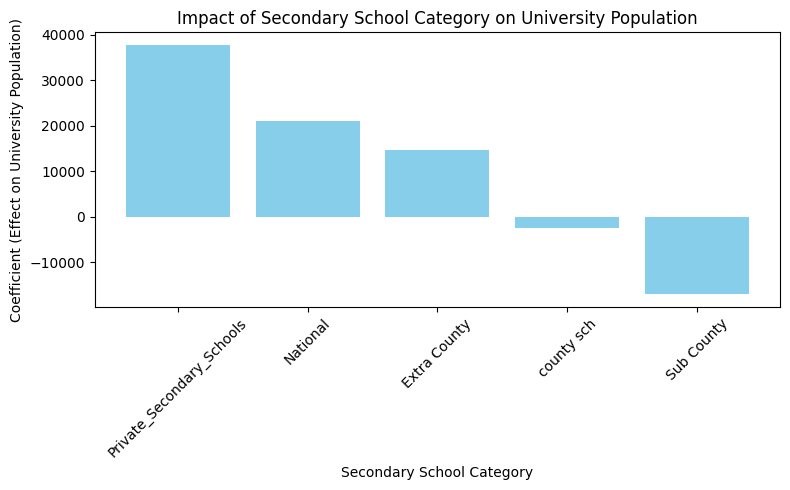

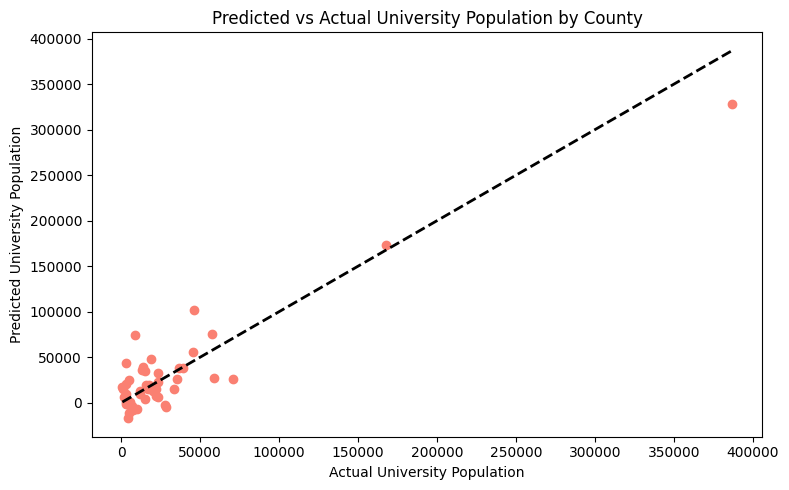

In [57]:

coeff_df = pd.DataFrame({
    "School_Category": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(coeff_df["School_Category"], coeff_df["Coefficient"], color="skyblue")
plt.title("Impact of Secondary School Category on University Population")
plt.ylabel("Coefficient (Effect on University Population)")
plt.xlabel("Secondary School Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Predicted vs Actual university population ---
y_pred = model.predict(X_scaled)

plt.figure(figsize=(8,5))
plt.scatter(y, y_pred, color="salmon")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)  # perfect prediction line
plt.xlabel("Actual University Population")
plt.ylabel("Predicted University Population")
plt.title("Predicted vs Actual University Population by County")
plt.tight_layout()
plt.show()


Coefficients for TVET model:
             School_Category  Coefficient
0                   National     0.636272
2                 county sch     0.392509
3                 Sub County     0.347472
4  Private_Secondary_Schools     0.252743
1               Extra County    -0.112654

R^2 score: 0.2855123787186852


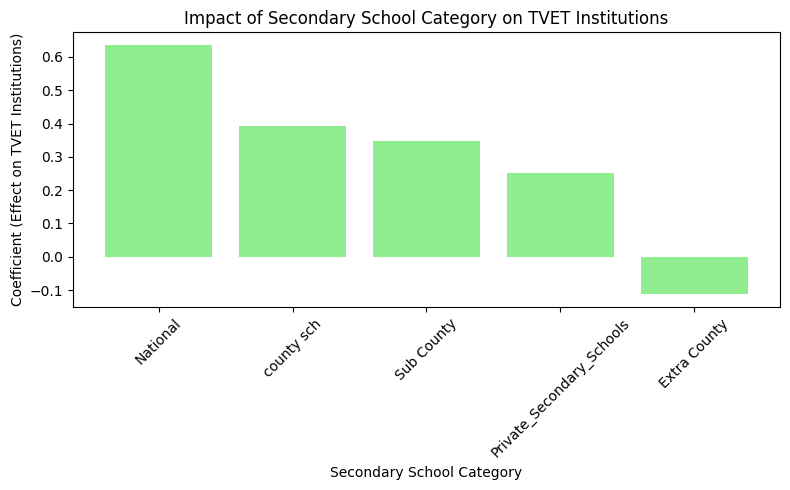

In [61]:

X_tvet = combined[["National", "Extra County", "county sch", "Sub County", "Private_Secondary_Schools"]].fillna(0)

# Scale features
scaler = StandardScaler()
X_scaled_tvet = scaler.fit_transform(X_tvet)

# --- Target ---
y_tvet = level_school_df["TVET_Schools"]

# --- Fit model ---
model_tvet = LinearRegression()
model_tvet.fit(X_scaled_tvet, y_tvet)

# --- Coefficients ---
coeff_tvet_df = pd.DataFrame({
    "School_Category": X_tvet.columns,
    "Coefficient": model_tvet.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Coefficients for TVET model:")
print(coeff_tvet_df)

# --- R^2 Score ---
r2_tvet = model_tvet.score(X_scaled_tvet, y_tvet)
print("\nR^2 score:", r2_tvet)

# --- Plot ---
plt.figure(figsize=(8,5))
plt.bar(coeff_tvet_df["School_Category"], coeff_tvet_df["Coefficient"], color="lightgreen")
plt.title("Impact of Secondary School Category on TVET Institutions")
plt.ylabel("Coefficient (Effect on TVET Institutions)")
plt.xlabel("Secondary School Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# TEVT Institutions Result

**Coefficients:**
- National (0.636), county sch (0.393), Sub County (0.347), Private Secondary (0.253) → positive association with TVET institutions.
- Extra County (-0.113) → slight negative association.
- Positive values indicate counties with more of these schools tend to have more TVET institutions.  

**R² Score:**
- 0.29 → model explains ~29% of variance in TVET institutions.
- Secondary school categories are moderate predictors; other factors (policy, population, local demand) also play a role.


